# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mirzaAsca/flyrank-internship-ml/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

I chose the **Growth / Recovery / Momentum Prediction lane** because it aligns with what I've been learning throughout the FlyRank ML internship. Coming from a supervised learning background, I'm still building my understanding of SEO, so I wanted to work on a problem that forces me to think carefully about problem framing before modeling. Predicting which pages are likely to decline is a practical business problem because it allows content teams to act before performance drops instead of reacting afterward. It also gives me the opportunity to apply machine learning principles such as avoiding data leakage, designing proper feature and target windows, and comparing ML against simple rule-based approaches before deciding whether the added complexity is worthwhile.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")


Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

# **Research Question**: Can we predict which content pages are likely to decline in performance during a future time window using only historical information?

The decision this project aims to improve is which content pages an SEO team should prioritize for review or updates. Rather than manually reviewing every page, the model would produce a ranked list of pages with the highest predicted risk of decline, allowing editors and SEO specialists to focus their limited time where it is likely to have the greatest impact.

A false positive means a healthy page is unnecessarily reviewed, resulting in wasted editorial effort and time.
 A false negative is potentially more costly because a page that is genuinely at risk of declining may not receive attention, leading to lost search visibility and organic traffic.
 The goal is therefore not to replace human judgment, but to provide better prioritization based on historical data while acknowledging the uncertainty in every prediction.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Key statistics
n_pages = df["content_id"].nunique()
n_clients = df["client_id"].nunique()
avg_impressions = df["impressions_90d"].mean()
corr = df["search_volume"].corr(df["impressions_90d"])

print(f"Unique content pages : {n_pages:,}")
print(f"Unique clients       : {n_clients}")
print(f"Average impressions/page (90d): {avg_impressions:,.0f}")
print(f"Correlation (Search Volume vs Impressions): {corr:.4f}")

Unique content pages : 30,000
Unique clients       : 32
Average impressions/page (90d): 5,200
Correlation (Search Volume vs Impressions): 0.0012


In [19]:
cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "engagement_rate"
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.0,3615.25,517715.0
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.0,7.00,4178.0
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.0,27.00,4345.0
engagement_rate,30000.0,2.534520,8.310096,0.0,0.0,0.0,1.35,100.0


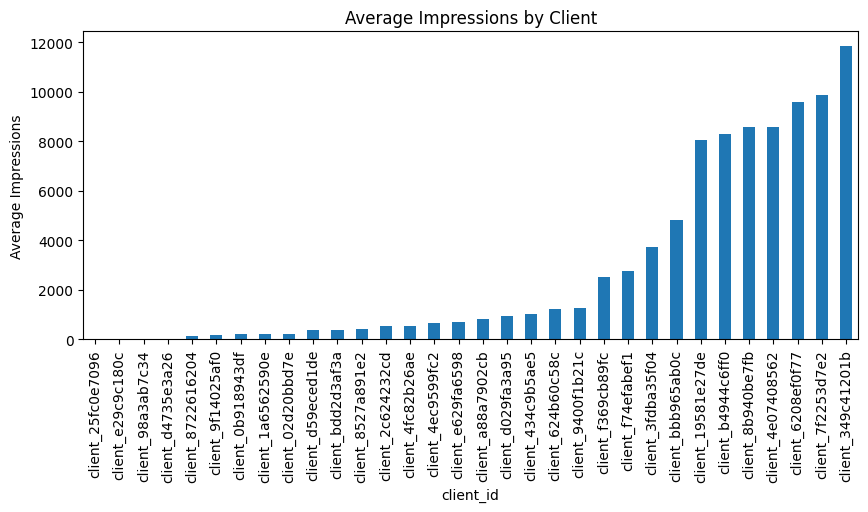

In [20]:
# Variation across clients
import matplotlib.pyplot as plt

client_perf = (
    df.groupby("client_id")["impressions_90d"]
      .mean()
      .sort_values()
)

client_perf.plot.bar(figsize=(10,4))

plt.ylabel("Average Impressions")
plt.title("Average Impressions by Client")

plt.show()

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

This project aims to develop a *decision-support model*  that **estimates** which content pages are more likely to decline in performance during a future time window based on historical SEO, traffic, engagement, and content features. The predictions should be interpreted as **probabilistic and directional,** helping SEO teams prioritize which pages to review first rather than making decisions automatically.

This work **cannot** prove why a page declines, demonstrate that updating a page will prevent decline, or claim to predict how Google's ranking algorithms behave. Any relationships learned by the model are observational rather than causal. The model identifies patterns present in historical data and provides evidence to support prioritization, but final decisions should still rely on *human judgment* and *domain expertise*.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.



## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.